Instructions on how to submit predictions to a Kaggle Competition via their API. More information [here](https://github.com/Kaggle/kaggle-api).

I will go into the details of the modelling process in a future post. This post is to simply highlight submission process.

## 1. Get Data 

In [1]:
from pathlib import Path
import zipfile,kaggle
path = Path('titanic')
kaggle.api.competition_download_cli(str(path))
zipfile.ZipFile(f'{path}.zip').extractall(path)

100%|██████████| 34.1k/34.1k [00:00<00:00, 287kB/s]

In [3]:
from fastai.tabular.all import *

In [4]:
df = pd.read_csv(path/'train.csv')

## 2. Prepare Data

### 2.1 Feature Engineering (FE)

I'll go into the details in a future post.

In [6]:
def add_features(df):
    df['LogFare'] = np.log1p(df['Fare'])
    df['Deck'] = df.Cabin.str[0].map(dict(A="ABC", B="ABC", C="ABC", D="DE", E="DE", F="FG", G="FG"))
    df['Family'] = df.SibSp+df.Parch
    df['Alone'] = df.Family==1
    df['TicketFreq'] = df.groupby('Ticket')['Ticket'].transform('count')
    df['Title'] = df.Name.str.split(', ', expand=True)[1].str.split('.', expand=True)[0]
    df['Title'] = df.Title.map(dict(Mr="Mr",Miss="Miss",Mrs="Mrs",Master="Master")).value_counts(dropna=False)

add_features(df)

### 2.2 Test and Validation sets

In [9]:
splits = RandomSplitter(seed=42)(df)

### 2.3 Create Tabular DataLoader

In [10]:
dls = TabularPandas(
    df, splits=splits,
    procs = [Categorify, FillMissing, Normalize],
    cat_names=["Sex","Pclass","Embarked","Deck", "Title"],
    cont_names=['Age', 'SibSp', 'Parch', 'LogFare', 'Alone', 'TicketFreq', 'Family'],
    y_names="Survived", y_block = CategoryBlock(),
).dataloaders(path=".")

c:\Users\tonyp\miniconda3\envs\fastai\Lib\site-packages\fastai\torch_core.py:263: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  return getattr(torch, 'has_mps', False)


## 3. Train our Learner

### 3.1 Create Learner

In [11]:
titanic_learner = tabular_learner(dls, metrics=accuracy, layers=[10,10])

### 3.2 Learner Rate

c:\Users\tonyp\miniconda3\envs\fastai\Lib\site-packages\fastai\torch_core.py:263: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  return getattr(torch, 'has_mps', False)


c:\Users\tonyp\miniconda3\envs\fastai\Lib\site-packages\fastai\torch_core.py:263: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  return getattr(torch, 'has_mps', False)
c:\Users\tonyp\miniconda3\envs\fastai\Lib\site-packages\fastai\torch_core.py:263: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  return getattr(torch, 'has_mps', False)
c:\Users\tonyp\miniconda3\envs\fastai\Lib\site-packages\fastai\torch_core.py:263: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  return getattr(torch, 'has_mps', False)
c:\Users\tonyp\miniconda3\envs\fastai\Lib\site-packages\fastai\torch_core.py:263: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  return getattr(torch, 'has_mps', False)
c:\Users\tonyp\miniconda3\envs\fastai\Lib\site-packages\fastai\torch_core.py:263: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  return getattr(

SuggestedLRs(slide=0.17378008365631104, valley=0.0063095735386013985)

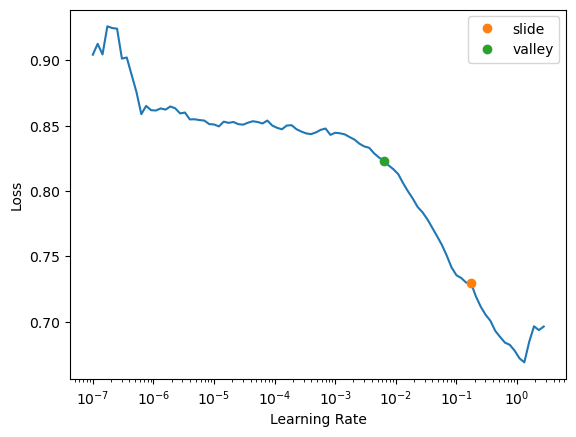

In [12]:
titanic_learner.lr_find(suggest_funcs=(slide, valley))

### 3.3 Training

In [13]:
titanic_learner.fit(16, lr=0.03)

c:\Users\tonyp\miniconda3\envs\fastai\Lib\site-packages\fastai\torch_core.py:263: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  return getattr(torch, 'has_mps', False)


epoch,train_loss,valid_loss,accuracy,time
0,0.596849,0.513625,0.764045,00:00
1,0.523100,0.441445,0.825843,00:00
2,0.486269,0.424140,0.814607,00:00
3,0.463389,0.435428,0.825843,00:00
4,0.449716,0.410079,0.814607,00:00
5,0.436479,0.421731,0.814607,00:00
6,0.426917,0.437185,0.803371,00:00
7,0.422690,0.422998,0.814607,00:00
8,0.415231,0.436206,0.814607,00:00
9,0.411327,0.419795,0.803371,00:00


c:\Users\tonyp\miniconda3\envs\fastai\Lib\site-packages\fastai\torch_core.py:263: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  return getattr(torch, 'has_mps', False)
c:\Users\tonyp\miniconda3\envs\fastai\Lib\site-packages\fastai\torch_core.py:263: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  return getattr(torch, 'has_mps', False)
c:\Users\tonyp\miniconda3\envs\fastai\Lib\site-packages\fastai\torch_core.py:263: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  return getattr(torch, 'has_mps', False)
c:\Users\tonyp\miniconda3\envs\fastai\Lib\site-packages\fastai\torch_core.py:263: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  return getattr(torch, 'has_mps', False)
c:\Users\tonyp\miniconda3\envs\fastai\Lib\site-packages\fastai\torch_core.py:263: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  return getattr(

## 4. Predictions

### 4.1 Import Test Data and Apply FE

In [ ]:
tst_df = pd.read_csv(path/'test.csv')
tst_df['Fare'] = tst_df.Fare.fillna(0)
add_features(tst_df)